### Build A Basic Chatbot with Langgraph (GRAPH API)

In [106]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [107]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it apends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]




In [108]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [109]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [110]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D30AF9C830>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D30AF9D130>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [111]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D312E98AF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D312E98380>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [112]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [113]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)
## Adding Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

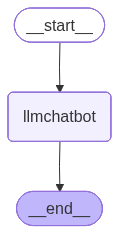

In [114]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [115]:
response = graph.invoke({"messages": "Hi"})

In [116]:
response["messages"][-1].content

'How can I assist you today?'

In [117]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How can I assist you today?


### Chatbot with Tool

In [118]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is Langgraph?")

{'query': 'What is Langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/en/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph - Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your 

In [119]:
## Custom function
def multiply(a:int, b:int) -> int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [120]:
tools = [tool, multiply]

In [121]:
llm_with_tool = llm.bind_tools(tools)

In [122]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D312E98AF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D312E98380>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

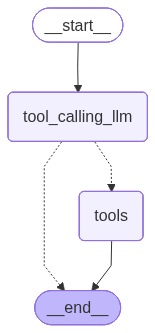

In [123]:
## Stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

## Compile the graph
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [124]:
response = graph.invoke({"messages": "What is the recent AI news?"})

In [125]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fool.com/investing/2026/06/01/nvidias-jensen-huang-just-announced-something-big/", "title": "Nvidia\'s Jensen Huang Just Announced Something Big - The Motley Fool", "score": 0.97068775, "published_date": "Mon, 01 Jun 2026 22:10:00 GMT", "content": "In recent years, **Nvidia** (NVDA +6.26%) has driven the artificial intelligence (AI) revolution by bringing its graphics processing units (GPUs) to data centers. As mentioned, Nvidia has built its dominance -- and earnings machine -- in recent years by serving the data center market with GPUs. These are the major tech giants, as well as other tech companies, that sell access to compute or use it for their own AI projects. Now, on top of this, Nvidia\'s Huang just announced big news -- something that could ensure the company\'s leadership and even propel it into leadership of a second market. This latest move allows Nvidia

In [126]:
for m in response["messages"]:
    m.pretty_print()
    

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (zfzmh34k4)
 Call ID: zfzmh34k4
  Args:
    query: recent AI news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fool.com/investing/2026/06/01/nvidias-jensen-huang-just-announced-something-big/", "title": "Nvidia's Jensen Huang Just Announced Something Big - The Motley Fool", "score": 0.97068775, "published_date": "Mon, 01 Jun 2026 22:10:00 GMT", "content": "In recent years, **Nvidia** (NVDA +6.26%) has driven the artificial intelligence (AI) revolution by bringing its graphics processing units (GPUs) to data centers. As mentioned, Nvidia has built its dominance -- and earnings machi

In [127]:
response = graph.invoke({"messages": "What is 5 multiplied by 2?"})
for m in response["messages"]:
    m.pretty_print()
    

================================ Human Message =================================

What is 5 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (0rq1xwwdt)
 Call ID: 0rq1xwwdt
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [128]:
response = graph.invoke({"messages": "Give me the recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()
    

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fjgdd61zf)
 Call ID: fjgdd61zf
  Args:
    query: recent ai news
    time_range: week
    topic: news
  multiply (4bd7hpqw0)
 Call ID: 4bd7hpqw0
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fool.com/investing/2026/06/01/nvidias-jensen-huang-just-announced-something-big/", "title": "Nvidia's Jensen Huang Just Announced Something Big - The Motley Fool", "score": 0.67269784, "published_date": "Mon, 01 Jun 2026 22:10:00 GMT", "content": "In recent years, **Nvidia** (NVDA +6.26%) has driven the artificial intelligence (AI) revolution by bringing its 

### ReAct Agent Architecture

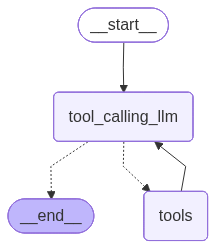

In [129]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [130]:
response = graph.invoke({"messages": "Give me the recent ai news and then multiply 5 by 10"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w3na8783s)
 Call ID: w3na8783s
  Args:
    query: recent AI news
    topic: news
  multiply (w837qd3b0)
 Call ID: w837qd3b0
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/tokenmaxxing-maxes-out-37103747", "title": "‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ", "score": 0.64236575, "published_date": "Sun, 31 May 2026 13:30:00 GMT", "content": "# ‘Tokenmaxxing’ AI Use Is Now Under Scrutiny | Technology for May 31 - WSJ. ## Plus, AI topples an 80-year-old math problem, the Brockmans sit for an interview and 

### Adding Memory in Agentic Graph

In [131]:
response = graph.invoke({"messages": "Hello my name is Pramod"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Pramod
================================== Ai Message ==================================

Nice to meet you, Pramod. Is there anything I can help you with today?


In [132]:
response = graph.invoke({"messages": "What is my name ?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name ?
================================== Ai Message ==================================

I don't have any information about your name. I'm a text-based AI assistant, and our conversation has just started. I don't have the ability to retain information about individual users or their personal details. If you'd like to share your name with me, I'd be happy to chat with you about it, but I won't be able to recall it if you don't tell me.


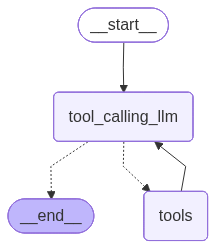

In [133]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [134]:
config = {"configurable": {"thread_id":"1"}}

response = graph.invoke({"messages": "Hi my name is Pramod"}, config=config)

response

{'messages': [HumanMessage(content='Hi my name is Pramod', additional_kwargs={}, response_metadata={}, id='02b524ac-38af-4e46-b057-96465702565d'),
  AIMessage(content='It was nice meeting you, Pramod. Is there anything I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1752, 'total_tokens': 1773, 'completion_time': 0.03807779, 'completion_tokens_details': None, 'prompt_time': 0.754209795, 'prompt_tokens_details': None, 'queue_time': 0.048514653, 'total_time': 0.792287585}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e931b-ad2f-72e3-8fbc-f0004aa2823f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1752, 'output_tokens': 21, 'total_tokens': 1773})]}

In [135]:
response["messages"][-1].content

'It was nice meeting you, Pramod. Is there anything I can help you with today?'

In [136]:
response = graph.invoke({"messages": "Hey, what is my name ?"}, config=config)

response["messages"][-1].content

'Your name is Pramod.'

In [137]:
response = graph.invoke({"messages": "Hey do you remember my name ?"}, config=config)

response["messages"][-1].content

'Your name is Pramod.'

### Streaming

In [157]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [158]:
def superbot(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

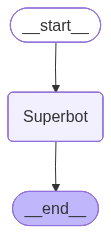

In [159]:
graph = StateGraph(State)

## Node
graph.add_node("Superbot", superbot)

## Edges
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [160]:
## Invocation

config = {"configurable": {"thread_id":"2"}}

response = graph_builder.invoke({"messages": "Hi, My name is Pramod and I like coding"}, config)
response

{'messages': [HumanMessage(content='Hi, My name is Pramod and I like coding', additional_kwargs={}, response_metadata={}, id='2552b92d-db02-4135-8052-0020dd97a669'),
  AIMessage(content='Nice to meet you Pramod. What do you like to code in?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1757, 'total_tokens': 1774, 'completion_time': 0.032174664, 'completion_tokens_details': None, 'prompt_time': 0.136784088, 'prompt_tokens_details': None, 'queue_time': 0.048115892, 'total_time': 0.168958752}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9335-915e-73c3-b9f4-79dc36a84641-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1757, 'output_tokens': 17, 'total_tokens': 1774})]}

In [161]:
response["messages"][-1].content

'Nice to meet you Pramod. What do you like to code in?'

### Streaming
Methods: **.stream()** and **astream()**

* These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

* **values** : This streams the full state of the graph after each node is called.
* **updates** : This streams updates to the state of the graph after each node is called.

In [147]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Pramod And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'vg32pvnny', 'function': {'arguments': '{"query":"cricket updates","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 1944, 'total_tokens': 1968, 'completion_time': 0.021729769, 'completion_tokens_details': None, 'prompt_time': 0.136168567, 'prompt_tokens_details': None, 'queue_time': 0.068971882, 'total_time': 0.157898336}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e932f-7861-79f2-8199-8f89a6c14072-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'cricket updates', 'topic': 'news'}, 'id': 'vg32pvnny', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1944, 'output_tokens': 24, 'total_tokens': 1968})]}}


In [148]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Pramod and I like coding', additional_kwargs={}, response_metadata={}, id='b51e2c97-0222-4d36-9998-2c734c7930f6'), AIMessage(content='Nice to meet you, Pramod. It sounds like you have a passion for coding. What programming languages or technologies have you been exploring or working with?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1757, 'total_tokens': 1790, 'completion_time': 0.071192595, 'completion_tokens_details': None, 'prompt_time': 0.593536779, 'prompt_tokens_details': None, 'queue_time': 0.113397579, 'total_time': 0.664729374}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e932d-6046-7d33-91c0-58027a2c8224-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1757, 'output_tokens': 33, 'total_tokens': 1790}),

In [150]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Pramod And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Nice to meet you, Pramod! Another cricket fan, eh? Do you play cricket yourself or just watch and enjoy it?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1801, 'total_tokens': 1829, 'completion_time': 0.06750273, 'completion_tokens_details': None, 'prompt_time': 0.240862563, 'prompt_tokens_details': None, 'queue_time': 0.104749304, 'total_time': 0.308365293}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9330-cfc9-7620-b426-07cd2d14b6d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1801, 'output_tokens': 28, 'total_tokens': 1829})]}}


In [152]:
for chunk in graph_builder.stream({'messages':"I also like volleyball"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="You're a fan of volleyball as well, I see. Do you have a favorite volleyball player or team that you like to watch?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1885, 'total_tokens': 1913, 'completion_time': 0.08827174, 'completion_tokens_details': None, 'prompt_time': 0.130491207, 'prompt_tokens_details': None, 'queue_time': 0.115664652, 'total_time': 0.218762947}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9331-d6a6-77a3-b504-ef04d457218b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1885, 'output_tokens': 28, 'total_tokens': 1913})]}}


In [156]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Pramod and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Pramod and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e9335-0151-78a3-ba69-9aa9ee3374c3', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='1ff00e43-562f-409b-ac7c-9b5e59048831'), AIMessage(content='Nice to meet you Krish. Cricket is a great sport. Would you like to know more about it?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'model_provider': 'groq'}, id='lc_run--019e9334-6594-7fe2-9b12-7f7440252ad2', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1756, 'output_tokens': 22, 'total_tokens': 1778}), HumanMessage(content='H